In [30]:
!pip install -q timm transformers

In [33]:
!find /kaggle/input -name "qualitative_attribution_kaggle.py"

/kaggle/input/datasets/tsumaiya64/cxr-attribution-code/qualitative_attribution_kaggle.py
^C


In [1]:
!ls /kaggle/input/datasets/nih-chest-xrays/data/images_*/images/00006425_005.png

/kaggle/input/datasets/nih-chest-xrays/data/images_003/images/00006425_005.png


In [2]:
!cp /kaggle/input/datasets/tsumaiya64/cxr-attribution-code/qualitative_attribution_kaggle.py /kaggle/working/attr.py

s = open("/kaggle/working/attr.py", newline="").read()
s = s.replace('root.rglob("*.png")',
              'map(Path, glob.glob(str(root / "**" / "*.png"), recursive=True))')
open("/kaggle/working/attr.py", "w", newline="").write(s)

14727

In [4]:
s = open("/kaggle/working/attr.py", newline="").read()

# 1. make 3 channels BEFORE normalizing (same as your training code)
s = s.replace('T.ToTensor(), T.Normalize(cfg["mean"], cfg["std"]),',
              'T.ToTensor(), T.Lambda(lambda t: t.repeat(3, 1, 1)), T.Normalize(cfg["mean"], cfg["std"]),')

# 2. the picture already has 3 channels now, so only add the batch dimension
s = s.replace("cnn_tfm(image).repeat(1, 3, 1, 1)", "cnn_tfm(image).unsqueeze(0)")
s = s.replace("vit_tfm(image).repeat(1, 3, 1, 1)", "vit_tfm(image).unsqueeze(0)")

open("/kaggle/working/attr.py", "w", newline="").write(s)

14754

In [5]:
!python /kaggle/working/attr.py

Loading weights: 100%|██████████████████████| 223/223 [00:00<00:00, 2739.66it/s]
Wrote 4 cases and figure files to /kaggle/working/qualitative_attribution
RAD-DINO method: gradient x activation over final patch tokens, not standard Grad-CAM.


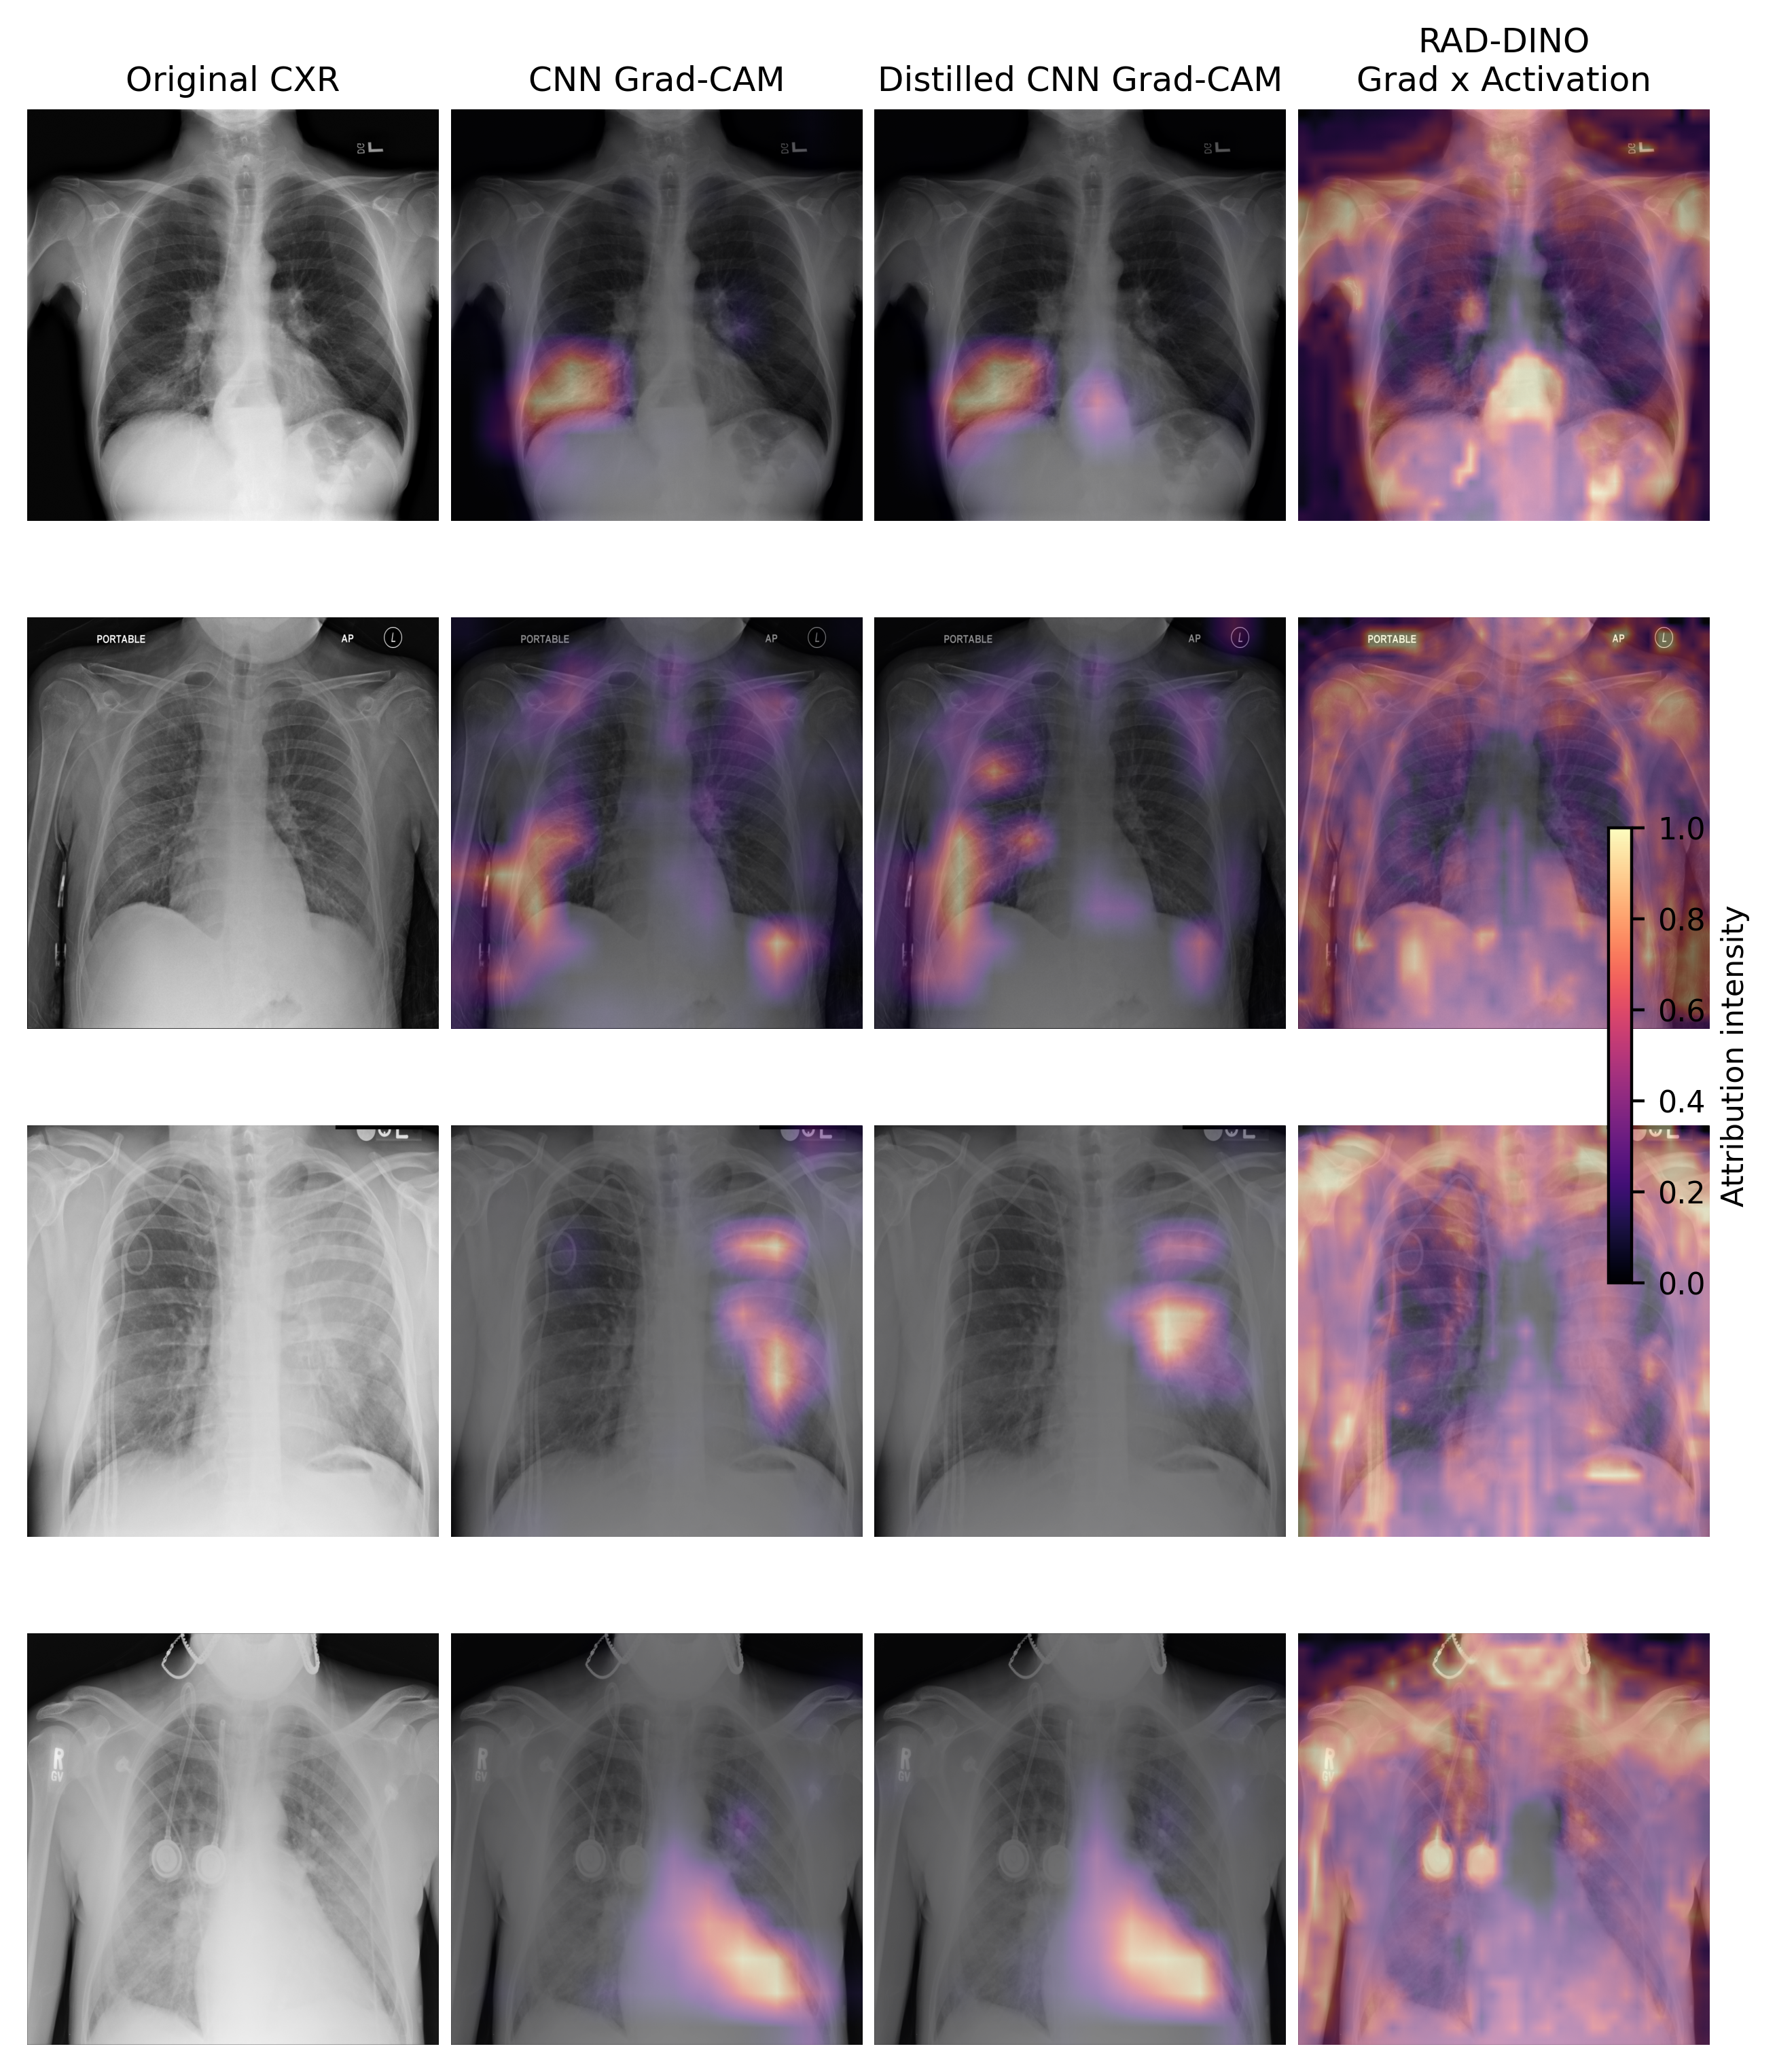

In [6]:
from IPython.display import Image
Image("/kaggle/working/qualitative_attribution/hard_positive_attribution.png")

In [7]:
import pandas as pd
pd.read_csv("/kaggle/working/qualitative_attribution/selected_cases.csv")

,row,image_index,target_finding,ground_truth,selection_rule,CNN alone_probability,CNN alone_threshold,CNN alone_prediction,Distilled CNN_probability,Distilled CNN_threshold,Distilled CNN_prediction,RAD-DINO alone_probability,RAD-DINO alone_threshold,RAD-DINO alone_prediction
0,1,00009507_004.png,Pneumonia,1,"GT=1, baseline=0, RAD-DINO=1, distilled=1",0.025626,0.063307,0,0.061449,0.036652,1,0.143042,0.082100,1
1,2,00017714_004.png,Infiltration,1,"GT=1, baseline=0, RAD-DINO=1, distilled=1",0.134063,0.164263,0,0.214979,0.193109,1,0.386831,0.180415,1
2,3,00006425_005.png,Mass,1,"GT=1, baseline=0, RAD-DINO=1, distilled=1",0.099833,0.136958,0,0.261903,0.176708,1,0.669862,0.226298,1
3,4,00006481_014.png,Cardiomegaly,1,"GT=1, baseline=0, RAD-DINO=1, distilled=1",0.074447,0.156697,0,0.234436,0.128926,1,0.403705,0.150334,1


In [8]:
import shutil
shutil.make_archive("/kaggle/working/attribution_output", "zip",
                    "/kaggle/working/qualitative_attribution")

'/kaggle/working/attribution_output.zip'

In [9]:
from IPython.display import FileLink
FileLink("attribution_output.zip")

/kaggle/working/attribution_output.zip